# asymptotics — ODE Perturbation Theory

This notebook covers regular perturbation theory for **ordinary differential equations** using `asymptotics.ODE`.

The workflow is identical to algebraic equations — write everything as strings, call `expand_regular`, inspect the result:

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u**3", dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])
sol = eq.expand_regular(order=2)
sol.show()
```

**Covered here:**
1. First-order IVP
2. Second-order IVP — the Duffing oscillator (secular terms)
3. Second-order IVP with damping
4. Linear BVP
5. Nonlinear BVP
6. Error checking

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import *
from IPython.display import display, Math
from asymptotics import ODE

t_sym = symbols('t')

---
## Example 1 — First-order IVP

$$u' + u + \varepsilon u^2 = 0, \qquad u(0) = 1$$

When $\varepsilon = 0$: $u_0' + u_0 = 0 \implies u_0 = e^{-t}$.

The nonlinear term $\varepsilon u^2$ perturbs this exponential decay.

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

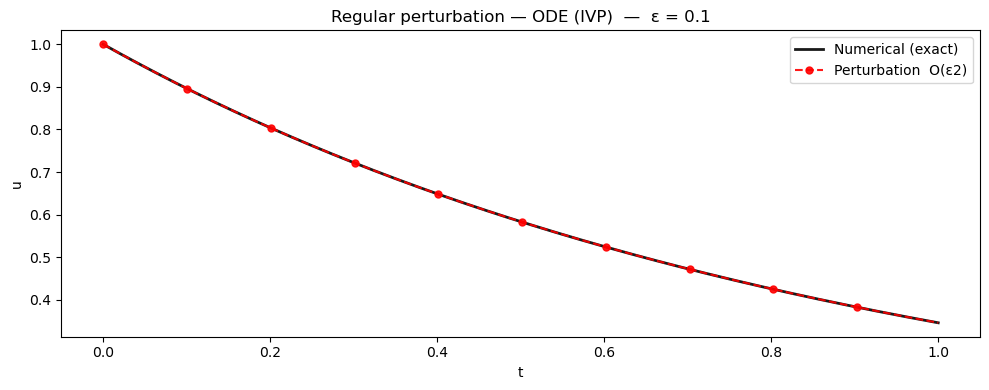

In [5]:
eq = ODE(
    "u' + u + eps*u**2",
    small_param = "eps",
    conditions  = ["u(0) = 1"],
)

sol = eq.expand_regular(order=2)

result = sol.compare_numeric(eps=0.1, problem=eq, plot_range=[0, 1])
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

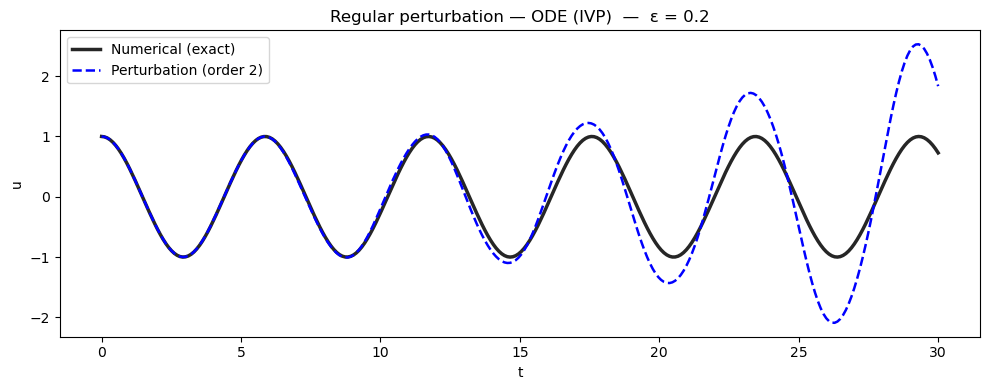

In [4]:
eq  = ODE(equation = "u'' + u + eps*u**3", 
          dependent= "u", 
          small_param="eps", 
          independent="t",
          conditions= ["u(0) = 1", "u'(0) = 0"])

# Regular perturbation
sol = eq.expand_regular(order=2)
result = sol.compare_numeric(eps=0.2, problem=eq, t_range=[0, 30])
sol.show()

### Numerical verification

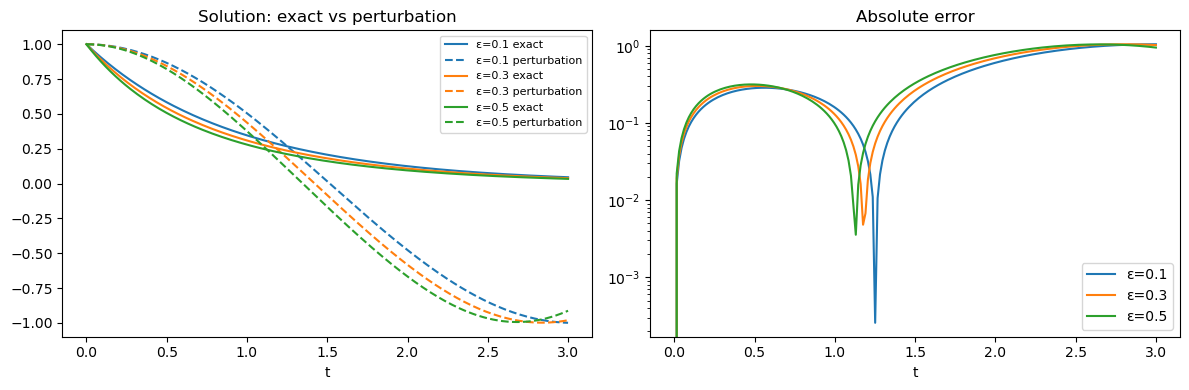

In [5]:
eps_sym = sol.small_param
comp    = lambdify(t_sym, sol.composite, 'numpy')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_vals = np.linspace(0, 3, 200)

for eps_val, color in [(0.1, 'C0'), (0.3, 'C1'), (0.5, 'C2')]:
    # Numerical solution
    def rhs(t, y): return [-y[0] - eps_val*y[0]**2]
    num = solve_ivp(rhs, [0, 3], [1.0], dense_output=True, rtol=1e-10)
    u_exact = num.sol(t_vals)[0]

    # Perturbation approximation
    comp_sub = lambdify(t_sym, sol.composite.subs(eps_sym, eps_val), 'numpy')
    u_pert   = comp_sub(t_vals)

    axes[0].plot(t_vals, u_exact,  '-',  color=color, label=f'ε={eps_val} exact')
    axes[0].plot(t_vals, u_pert,   '--', color=color, label=f'ε={eps_val} perturbation')
    axes[1].semilogy(t_vals, np.abs(u_exact - u_pert), color=color, label=f'ε={eps_val}')

axes[0].set_title("Solution: exact vs perturbation")
axes[0].set_xlabel("t"); axes[0].legend(fontsize=8)
axes[1].set_title("Absolute error")
axes[1].set_xlabel("t"); axes[1].legend()
plt.tight_layout()
plt.show()

---
## Example 2 — Duffing oscillator (secular terms)

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = 1, \quad u'(0) = 0$$

The **Duffing oscillator** — a nonlinear spring. The unperturbed solution is $u_0 = \cos t$.

⚠️ **Secular terms appear at $\mathcal{O}(\varepsilon)$** — terms like $t\sin t$ that grow without bound. This means the regular perturbation expansion is only valid for small $t$. For a **uniformly valid** expansion, use Lindstedt–Poincaré (coming soon).

In [8]:
eq = ODE(
    "u'' + u + eps*u**3",
    dependent   = "u",
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.expand_regular(order=2)
sol.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

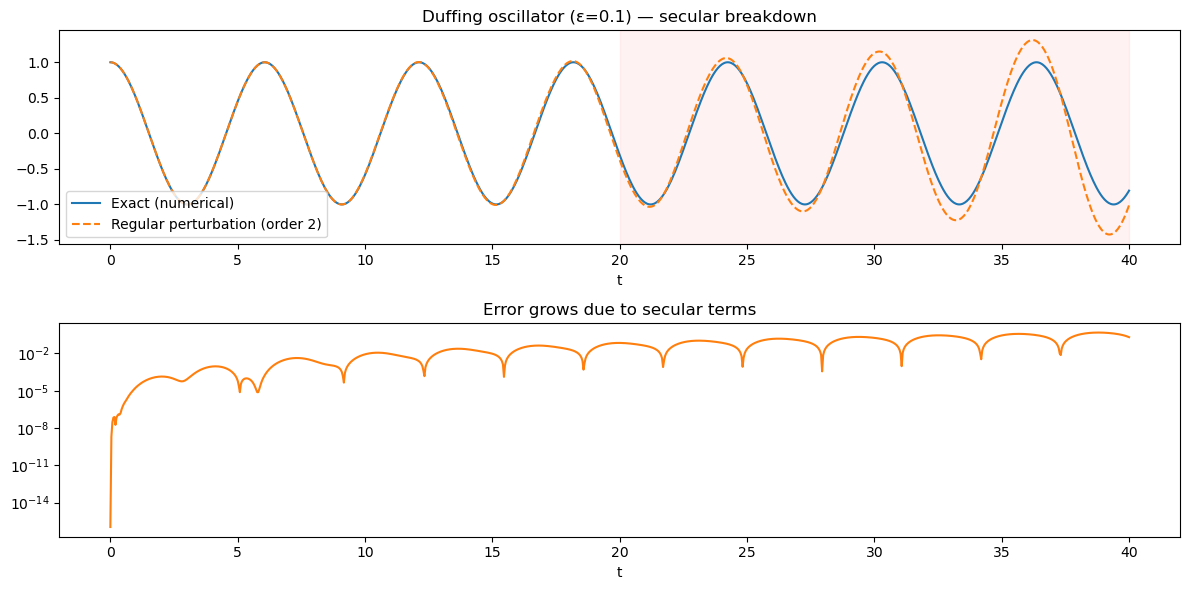

The regular perturbation series breaks down because of secular terms (t·sin t).
Fix: use Lindstedt-Poincaré or multiple scales — coming soon in asymptotics.


In [5]:
# Show that secular terms cause breakdown for large t
eps_val  = 0.1
t_long   = np.linspace(0, 40, 1000)

def rhs_duffing(t, y): return [y[1], -y[0] - eps_val*y[0]**3]
num = solve_ivp(rhs_duffing, [0, 40], [1.0, 0.0], dense_output=True, rtol=1e-10)
u_exact = num.sol(t_long)[0]

comp_sub = lambdify(t_sym, sol.composite.subs(sol.small_param, eps_val), 'numpy')
u_pert   = comp_sub(t_long)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t_long, u_exact, '-',  label='Exact (numerical)', lw=1.5)
axes[0].plot(t_long, u_pert,  '--', label='Regular perturbation (order 2)', lw=1.5)
axes[0].set_title(f"Duffing oscillator (ε={eps_val}) — secular breakdown")
axes[0].set_xlabel("t"); axes[0].legend()
axes[0].axvspan(20, 40, alpha=0.05, color='red', label='breakdown region')

axes[1].semilogy(t_long, np.abs(u_exact - u_pert), 'C1', lw=1.5)
axes[1].set_title("Error grows due to secular terms")
axes[1].set_xlabel("t")
plt.tight_layout()
plt.show()

print("The regular perturbation series breaks down because of secular terms (t·sin t).")
print("Fix: use Lindstedt-Poincaré or multiple scales — coming soon in asymptotics.")

---
## Example 3 — Second-order IVP with weak damping

$$u'' + \varepsilon u' + u = 0, \qquad u(0) = 1, \quad u'(0) = 0$$

Weak damping — the $\varepsilon u'$ term gradually suppresses oscillations. Unperturbed: $u_0 = \cos t$.

In [6]:
eq = ODE(
    "u'' + eps*u' + u",
    dependent   = "u",
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.expand_regular(order=2)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

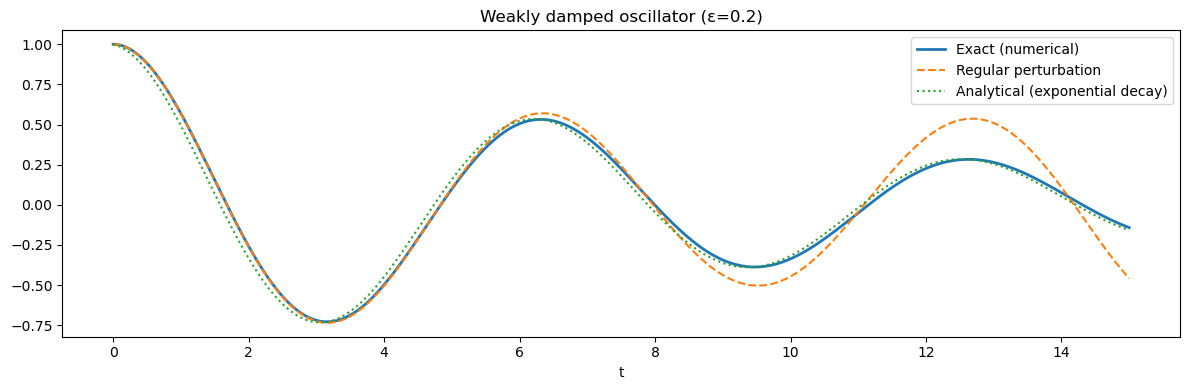

Note: secular terms appear (t·sin t, t²·cos t) — perturbation breaks down for large t.
The exponential envelope e^{-εt/2} is not captured by a polynomial in ε.


In [7]:
eps_val = 0.2
t_vals  = np.linspace(0, 15, 500)

def rhs_damped(t, y): return [y[1], -y[0] - eps_val*y[1]]
num     = solve_ivp(rhs_damped, [0, 15], [1.0, 0.0], dense_output=True, rtol=1e-10)
u_exact = num.sol(t_vals)[0]

comp_sub = lambdify(t_sym, sol.composite.subs(sol.small_param, eps_val), 'numpy')
u_pert   = comp_sub(t_vals)

# Exact solution: u = e^{-eps*t/2} * cos(sqrt(1-eps^2/4)*t) approximately
u_analytical = np.exp(-eps_val*t_vals/2) * np.cos(np.sqrt(1 - eps_val**2/4)*t_vals)

plt.figure(figsize=(12, 4))
plt.plot(t_vals, u_exact,      '-',  label='Exact (numerical)',      lw=2)
plt.plot(t_vals, u_pert,       '--', label='Regular perturbation',   lw=1.5)
plt.plot(t_vals, u_analytical, ':',  label='Analytical (exponential decay)', lw=1.5)
plt.title(f"Weakly damped oscillator (ε={eps_val})")
plt.xlabel("t"); plt.legend()
plt.tight_layout()
plt.show()

print("Note: secular terms appear (t·sin t, t²·cos t) — perturbation breaks down for large t.")
print("The exponential envelope e^{-εt/2} is not captured by a polynomial in ε.")

---
## Example 4 — Linear BVP

$$u'' + \varepsilon u = 0, \qquad u(0) = 0, \quad u(1) = 1$$

The unperturbed problem $u_0'' = 0$ with $u_0(0)=0$, $u_0(1)=1$ gives $u_0 = t$.

Each order correction satisfies **homogeneous** boundary conditions $u_k(0) = u_k(1) = 0$.

In [11]:
eq = ODE(
    "u'' + eps*u",
    small_param = "eps",
    conditions  = ["u(0) = 0", "u(1) = 1"],
)

sol = eq.expand_regular(order=3)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [12]:
# Verify boundary conditions are exactly satisfied at every order
print("Boundary condition verification at each order:")
for entry in sol.entries:
    u_k = entry.particular_solution
    at0 = simplify(u_k.subs(t_sym, 0))
    at1 = simplify(u_k.subs(t_sym, 1))
    label = "u₀" if entry.order == 0 else f"u_{entry.order}"
    display(Math(
        f"{label}(0) = {latex(at0)}, \\quad {label}(1) = {latex(at1)}"
        + (r"\quad \checkmark" if at0 == 0 and (at1 == 1 if entry.order == 0 else at1 == 0) else r"\quad \times")
    ))

Boundary condition verification at each order:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

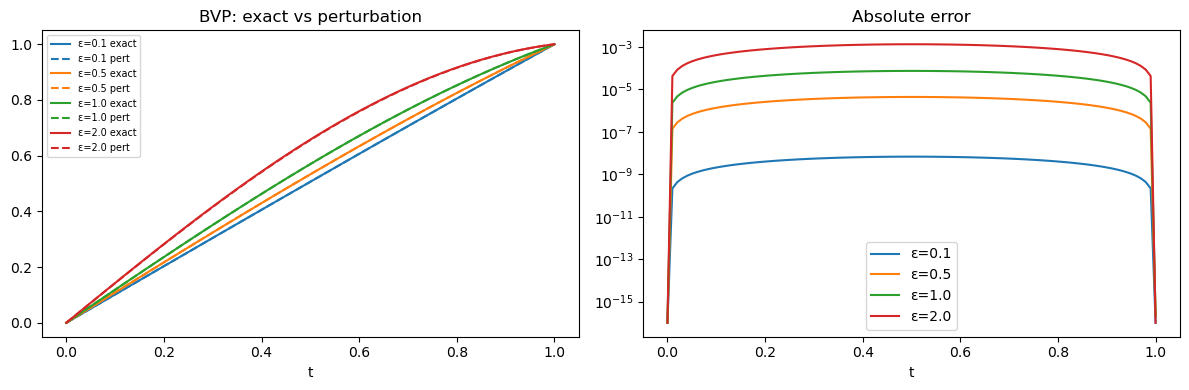

In [10]:
# Numerical comparison
from scipy.integrate import solve_bvp

t_vals = np.linspace(0, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_val, color in [(0.1, 'C0'), (0.5, 'C1'), (1.0, 'C2'), (2.0, 'C3')]:
    # Numerical BVP solution
    def bvp_rhs(t, y): return [y[1], -eps_val*y[0]]
    def bvp_bc(ya, yb): return [ya[0], yb[0] - 1]
    y_init = np.zeros((2, t_vals.size))
    y_init[0] = t_vals
    num = solve_bvp(bvp_rhs, bvp_bc, t_vals, y_init)
    u_exact = num.sol(t_vals)[0]

    # Perturbation
    comp_sub = lambdify(t_sym, sol.composite.subs(sol.small_param, eps_val), 'numpy')
    u_pert   = comp_sub(t_vals)

    axes[0].plot(t_vals, u_exact, '-',  color=color, label=f'ε={eps_val} exact')
    axes[0].plot(t_vals, u_pert,  '--', color=color, label=f'ε={eps_val} pert')
    axes[1].semilogy(t_vals, np.abs(u_exact - u_pert) + 1e-16, color=color, label=f'ε={eps_val}')

axes[0].set_title("BVP: exact vs perturbation")
axes[0].set_xlabel("t"); axes[0].legend(fontsize=7)
axes[1].set_title("Absolute error")
axes[1].set_xlabel("t"); axes[1].legend()
plt.tight_layout()
plt.show()

---
## Example 5 — Nonlinear BVP

$$u'' + \varepsilon u^2 = 0, \qquad u(0) = 0, \quad u(1) = 1$$

The nonlinear term $\varepsilon u^2$ bends the linear profile $u_0 = t$.

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

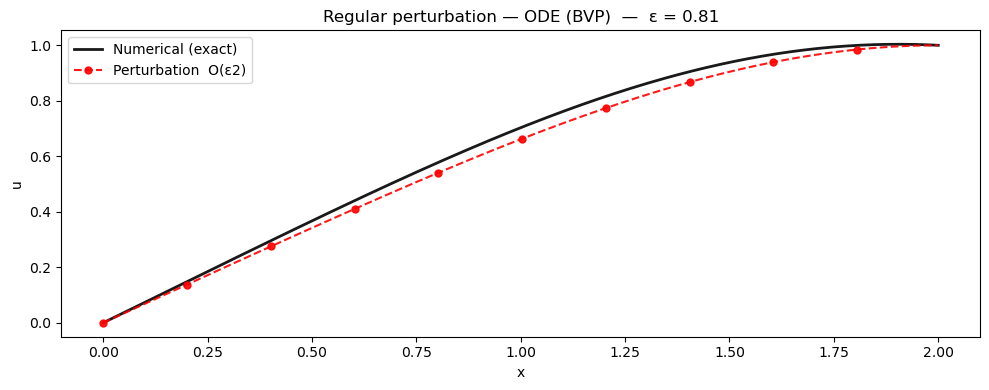

In [24]:
eq = ODE(
    "u'' + eps*u**2",
    small_param = "eps",
    conditions  = ["u(0) = 0", "u(2) = 1"],
)

sol = eq.expand_regular(order=2)
sol.compare_numeric(eps=0.81,problem=eq,t_range=[0,2])
sol.show()

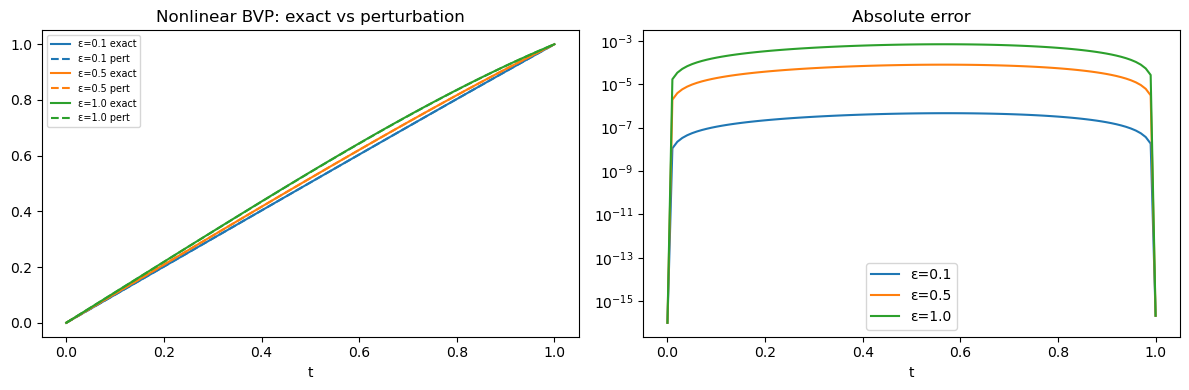

In [12]:
t_vals = np.linspace(0, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_val, color in [(0.1, 'C0'), (0.5, 'C1'), (1.0, 'C2')]:
    # Numerical BVP
    def bvp_rhs(t, y): return [y[1], -eps_val*y[0]**2]
    def bvp_bc(ya, yb): return [ya[0], yb[0] - 1]
    y_init = np.zeros((2, t_vals.size))
    y_init[0] = t_vals
    num = solve_bvp(bvp_rhs, bvp_bc, t_vals, y_init)
    u_exact = num.sol(t_vals)[0]

    comp_sub = lambdify(t_sym, sol.composite.subs(sol.small_param, eps_val), 'numpy')
    u_pert   = comp_sub(t_vals)

    axes[0].plot(t_vals, u_exact, '-',  color=color, label=f'ε={eps_val} exact')
    axes[0].plot(t_vals, u_pert,  '--', color=color, label=f'ε={eps_val} pert')
    axes[1].semilogy(t_vals, np.abs(u_exact - u_pert) + 1e-16, color=color, label=f'ε={eps_val}')

axes[0].set_title("Nonlinear BVP: exact vs perturbation")
axes[0].set_xlabel("t"); axes[0].legend(fontsize=7)
axes[1].set_title("Absolute error")
axes[1].set_xlabel("t"); axes[1].legend()
plt.tight_layout()
plt.show()

---
## Example 6 — Error checking

asymptotics catches common mistakes with clear messages.

In [13]:
from asymptotics import ODE
from asymptotics.core.conditions import ConditionError

# 1. Too many conditions
try:
    ODE("u'' + u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1", "u'(0) = 0", "u(1) = 0"])
except ConditionError as e:
    print("Too many conditions:", e)

# 2. Too few conditions
try:
    ODE("u'' + u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1"])
except ConditionError as e:
    print("Too few conditions:", e)

# 3. Conflicting conditions
try:
    ODE("u'' + u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1", "u(0) = 2"])
except ConditionError as e:
    print("Conflicting conditions:", e)

# 4. Wrong variable name
try:
    ODE("u' + u", dependent="u", small_param="eps", independent="t",
        conditions=["v(0) = 1"])
except ConditionError as e:
    print("Wrong variable:", e)

# 5. No derivatives found
try:
    ODE("u + eps*u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1"])
except ValueError as e:
    print("No derivatives:", e)

Too many conditions: 

  3 condition(s) provided but the ODE is order 2 — need exactly 2.

  Hint: for a 2nd-order ODE you need 2 conditions, e.g.:
    IVP: ["u(0) = 1", "u'(0) = 0"]
    BVP: ["u(0) = 0", "u(1) = 1"]

Too few conditions: 

  1 condition(s) provided but the ODE is order 2 — need exactly 2.

  Hint: for a 2nd-order ODE you need 2 conditions, e.g.:
    IVP: ["u(0) = 1", "u'(0) = 0"]
    BVP: ["u(0) = 0", "u(1) = 1"]

Conflicting conditions: 

  Conflicting conditions at t=0:
    u(0) = 1
    u(0) = 2

Wrong variable: 

  Condition 'v(0) = 1' refers to variable 'v'
  but the dependent variable is 'u'.

  Did you mean 'u(0) = 1'?

No derivatives: 

  No derivatives of 'u' found in equation 'u + eps*u'.
  Use prime notation: u' for first derivative, u'' for second.



---
## API quick reference

```python
from asymptotics import ODE

# IVP — 1st order
eq = ODE("u' + u + eps*u**2",
         dependent="u", small_param="eps", independent="t",
         conditions=["u(0) = 1"])

# IVP — 2nd order
eq = ODE("u'' + u + eps*u**3",
         dependent="u", small_param="eps", independent="t",
         conditions=["u(0) = 1", "u'(0) = 0"])

# BVP — 2nd order
eq = ODE("u'' + eps*u",
         dependent="u", small_param="eps", independent="t",
         conditions=["u(0) = 0", "u(1) = 1"])

# Expand
sol = eq.expand_regular(order=2)

# Display
sol.show()                          # full hierarchy (LaTeX in Jupyter)
sol.show(orders=[0, 1])             # specific orders
sol.show(mode='text')               # plain text

# Access results
sol[k].ode                          # ODE at order k
sol[k].general_solution             # with free constants
sol[k].particular_solution         # constants fixed by BCs/ICs
sol[k].secular                      # True if secular terms detected
sol.composite                       # full expansion u(t,ε)
sol.small_param                     # the ε symbol
sol.independent                     # the t symbol
sol._problem_type                   # 'ivp' or 'bvp'
```

**Supported derivative notation:**
- `u'`  → $u'$ (first derivative)
- `u''` → $u''$ (second derivative)

**Standard functions work out of the box:** `sin`, `cos`, `exp`, `log`, `tan`, `sqrt`, ...

In [16]:
eq = ODE(
    "u'' + u + eps*u**3",
    dependent   = "u",
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.expand_lindstedt(order=3)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [17]:
# Show that secular terms cause breakdown for large t
eps_val  = 0.1
t_long   = np.linspace(0, 40, 1000)

def rhs_duffing(t, y): return [y[1], -y[0] - eps_val*y[0]**3]
num = solve_ivp(rhs_duffing, [0, 40], [1.0, 0.0], dense_output=True, rtol=1e-10)
u_exact = num.sol(t_long)[0]

comp_sub = lambdify(t_sym, sol.composite.subs(sol.small_param, eps_val), 'numpy')
u_pert   = comp_sub(t_long)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t_long, u_exact, '-',  label='Exact (numerical)', lw=1.5)
axes[0].plot(t_long, u_pert,  '--', label='Regular perturbation (order 2)', lw=1.5)
axes[0].set_title(f"Duffing oscillator (ε={eps_val}) — secular breakdown")
axes[0].set_xlabel("t"); axes[0].legend()
axes[0].axvspan(20, 40, alpha=0.05, color='red', label='breakdown region')

axes[1].semilogy(t_long, np.abs(u_exact - u_pert), 'C1', lw=1.5)
axes[1].set_title("Error grows due to secular terms")
axes[1].set_xlabel("t")
plt.tight_layout()
plt.show()

print("The regular perturbation series breaks down because of secular terms (t·sin t).")
print("Fix: use Lindstedt-Poincaré or multiple scales — coming soon in asymptotics.")

TypeError: loop of ufunc does not support argument 0 of type Symbol which has no callable cos method